In [3]:
from dynamic_new import *

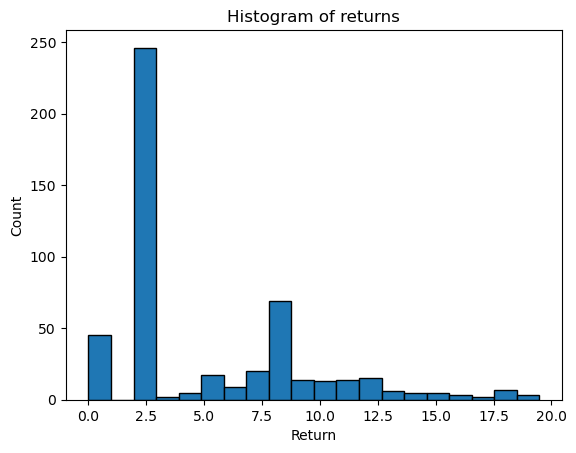

19.48


In [8]:
import matplotlib.pyplot as plt
env = GridWorld(7,size=8, danger=[7,1],goal=[4,5],wall=[2,5],coins=[(1,6),(4,2),(5,5)], horizon=50) ##set value of k here
pi = Policy(grid_size=8, action_dim=4)
# env.sparse=True
def get_return():
    s = env.reset()
    done = False
    temp = []
    while not done:
        a, _ = pi.act(s)
        s, done = env.step(a)
    return env.true_return()

temp = []
maxi = 0
for i in range(500):
    temp.append(get_return())
    maxi = max(maxi,temp[-1])
    
plt.hist(temp, bins=20, edgecolor='black')
plt.xlabel('Return')
plt.ylabel('Count')
plt.title('Histogram of returns')
plt.show()
print(maxi)

In [9]:
policy,queries,human_effort,steps,average_returns=train(n=300, num_traj=100,m=50,eta=0.5,epsilon=0.1, alpha=0.99 ,grid_size=8,danger=[7,1],goal=[4,5],wall=[2,5],horizon=50,coins=None,seed=1, noise=0.1,sparse=False)

threshold: 9.1888
itration number: 0
average reward: 4.93184
average feedback: 0.22
threshold: 20.884000000000004
itration number: 1
average reward: 9.919200000000002
average feedback: 0.02
threshold: 20.288000000000004
itration number: 2
average reward: 10.4968
average feedback: 0.06
threshold: 21.170400000000047
itration number: 3
average reward: 11.92688
average feedback: 0.1
threshold: 27.538000000000007
itration number: 4
average reward: 12.885440000000001
average feedback: 0.08
threshold: 21.73440000000003
itration number: 5
average reward: 13.941280000000004
average feedback: 0.04
threshold: 21.724400000000024
itration number: 6
average reward: 12.942560000000004
average feedback: 0.06
threshold: 27.558000000000018
itration number: 7
average reward: 14.45888
average feedback: 0.08
threshold: 30.328000000000003
itration number: 8
average reward: 14.45584
average feedback: 0.04
threshold: 21.68
itration number: 9
average reward: 13.04016
average feedback: 0.08
threshold: 21.744400

iterations to convergence to optimal policy: 7311


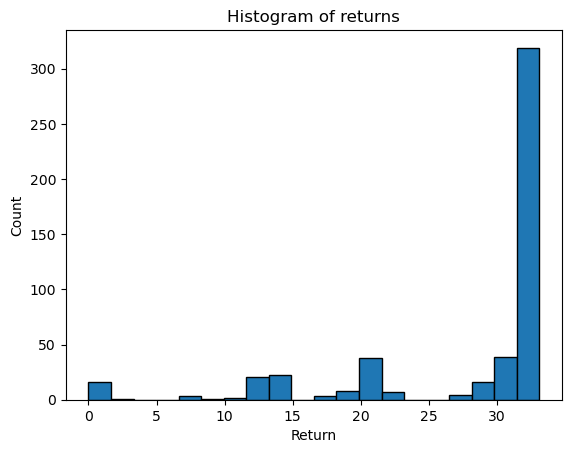

33.120000000000005


In [10]:
import matplotlib.pyplot as plt
print(f"iterations to convergence to optimal policy: {steps}")
env = GridWorld(7,size=8, danger=[7,1],goal=[4,5],wall=[2,5],coins=[(1,6),(4,2),(5,5)], horizon=50) ##set value of k here
pi = policy
# env.sparse=True
def get_return():
    s = env.reset()
    done = False
    temp = []
    while not done:
        a, _ = pi.act(s)
        s, done = env.step(a)
    return env.true_return()

temp = []
maxi = 0
for i in range(500):
    temp.append(get_return())
    maxi = max(maxi,temp[-1])
    
plt.hist(temp, bins=20, edgecolor='black')
plt.xlabel('Return')
plt.ylabel('Count')
plt.title('Histogram of returns')
plt.show()
print(maxi)

coin found at position: (1, 6)
coin found at position: (4, 2)
goal reached!
33


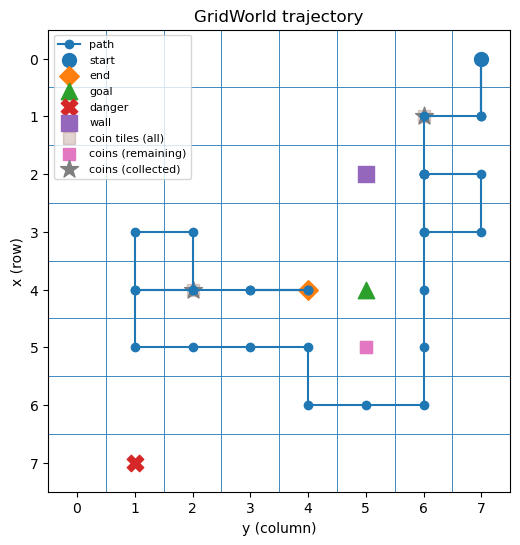

In [11]:
import matplotlib.pyplot as plt

def plot_gridworld_path(env, states):
    size = env.size
    xs = [s[1] for s in states]
    ys = [s[0] for s in states]
    fig, ax = plt.subplots(figsize=(6, 6))

    for i in range(size + 1):
        ax.axhline(i - 0.5, linewidth=0.6)
        ax.axvline(i - 0.5, linewidth=0.6)
    ax.set_xlim(-0.5, size - 0.5)
    ax.set_ylim(-0.5, size - 0.5)
    ax.set_aspect('equal', adjustable='box')
    ax.invert_yaxis()

    ax.plot(xs, ys, marker='o', linewidth=1.5, label='path')
    if states:
        ax.scatter(xs[0], ys[0], marker='o', s=100, label='start')
        ax.scatter(xs[-1], ys[-1], marker='D', s=100, label='end')

    gx, gy = env.goal
    dx, dy = env.danger
    ax.scatter(gy, gx, marker='^', s=140, label='goal')
    ax.scatter(dy, dx, marker='X', s=140, label='danger')

    wx, wy = env.wall
    ax.scatter(wy, wx, marker='s', s=140, label='wall')

    init_coins = list(env._init_coins)
    remaining = list(env.coins)
    collected = list(env.collected_coins)

    if init_coins:
        ax.scatter(
            [c[1] for c in init_coins],
            [c[0] for c in init_coins],
            marker='s', s=80, alpha=0.25, label='coin tiles (all)'
        )

    if remaining:
        ax.scatter(
            [c[1] for c in remaining],
            [c[0] for c in remaining],
            marker='s', s=80, label='coins (remaining)'
        )

    if collected:
        ax.scatter(
            [c[1] for c in collected],
            [c[0] for c in collected],
            marker='*', s=180, label='coins (collected)'
        )

    ax.set_xticks(range(size))
    ax.set_yticks(range(size))
    ax.set_xlabel('y (column)')
    ax.set_ylabel('x (row)')
    ax.set_title('GridWorld trajectory')
    ax.legend(loc='upper left', fontsize=8)
    plt.show()


    
done = 0
traj = {"states": [], "actions": [], "steps": 0, "coins": 0}

s = env.reset() 
c = set([(1,6),(4,2),(5,5)])
while not done:
    a, _ = pi.act(s)
    traj["states"].append(s)
    traj["actions"].append(a)
    s, done = env.step(a)
    if (s in c):
        print(f"coin found at position: {s}")
        c.remove(s)
    if (s == env.goal):
        print("goal reached!")
    if (s == env.danger):
        print("danger zone")
        
print(env.t)

plot_gridworld_path(env, traj["states"])

In [12]:
queries

148250

In [13]:
human_effort

154250

In [8]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
from contextlib import redirect_stdout

def pad_to_max_length(curves, pad_value=np.nan):
    max_len = max(len(c) for c in curves)
    out = np.full((len(curves), max_len), pad_value, dtype=float)
    for i, c in enumerate(curves):
        out[i, :len(c)] = c
    return out

def run_5_seeds_and_save_binary_dynamic(
    train_fn,
    base_train_kwargs,
    seeds=(0,1,2,3,4),
    out_dir="plot1_model_free",
    label="dynamic_binary",
    silence_prints=False,
):
    os.makedirs(out_dir, exist_ok=True)

    per_seed_curves = []
    per_seed_final = []
    per_seed_total_steps = []
    per_seed_total_queries = []
    per_seed_total_effort = []

    for seed in seeds:
        kwargs = dict(base_train_kwargs)
        kwargs["seed"] = seed
        print(f"\n=== Running seed {seed} ===")

        log_path = os.path.join(out_dir, f"{label}_seed{seed}_log.txt")
        if silence_prints:
            with open(log_path, "w") as f, redirect_stdout(f):
                policy, queries, human_effort, steps, average_returns = train_fn(**kwargs)
        else:
            policy, queries, human_effort, steps, average_returns = train_fn(**kwargs)

        curve = np.asarray(average_returns, dtype=float)
        per_seed_curves.append(curve)
        per_seed_final.append(float(curve[-1]) if len(curve) else np.nan)
        per_seed_total_steps.append(int(steps))
        per_seed_total_queries.append(int(queries))
        per_seed_total_effort.append(int(human_effort))

        np.save(os.path.join(out_dir, f"{label}_seed{seed}_curve.npy"), curve)

    curves_mat = pad_to_max_length(per_seed_curves, pad_value=np.nan)
    mean_curve = np.nanmean(curves_mat, axis=0)
    std_curve  = np.nanstd(curves_mat, axis=0)
    x = np.arange(len(mean_curve), dtype=float)

    np.save(os.path.join(out_dir, f"{label}_mean_curve.npy"), mean_curve)
    np.save(os.path.join(out_dir, f"{label}_std_curve.npy"), std_curve)
    np.save(os.path.join(out_dir, f"{label}_x_updates.npy"), x)

    summary = {
        "label": label,
        "seeds": list(seeds),
        "train_kwargs": base_train_kwargs,
        "final_return_per_seed": per_seed_final,
        "final_return_mean": float(np.nanmean(per_seed_final)),
        "final_return_std": float(np.nanstd(per_seed_final)),
        "total_steps_per_seed": per_seed_total_steps,
        "total_queries_per_seed": per_seed_total_queries,
        "total_human_effort_per_seed": per_seed_total_effort,
        "curve_len_per_seed": [int(len(c)) for c in per_seed_curves],
    }
    with open(os.path.join(out_dir, f"{label}_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)

    # Plot
    plt.figure(figsize=(8, 4.8))
    for c in per_seed_curves:
        plt.plot(np.arange(len(c)), c, alpha=0.25, linewidth=1)
    plt.plot(x, mean_curve, linewidth=2, label="mean (5 seeds)")
    plt.fill_between(x, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2, label="±1 std")
    plt.xlabel("Training update step")
    plt.ylabel("Avg true return")
    plt.title(label)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{label}.png"), dpi=200)
    plt.close()

    print(f"Saved: {label}.png")
    print(f"Final avg true return: {summary['final_return_mean']:.3f} ± {summary['final_return_std']:.3f}")
    return summary


In [9]:
noise_list = [0.1, 0.5, 0.8]
base_kwargs = dict(
    n=300, num_traj=100, m=50, eta=0.5, epsilon=0.1, alpha=0.99,
    grid_size=8, danger=[7,1], goal=[4,5], wall=[2,5], horizon=50, coins=None,
)

for sparse in [False, True]:
    for noise in noise_list:
        kwargs = dict(base_kwargs)
        kwargs["noise"] = noise
        kwargs["sparse"] = sparse
        label = f"dynamic_binary_alpha0p9_noise{noise}_sparse{sparse}"

        run_5_seeds_and_save_binary_dynamic(
            train_fn=train,
            base_train_kwargs=kwargs,
            seeds=(0,1,2,3,4),
            out_dir="plot1_model_free_dynamic_fixed",
            label=label,
        )



=== Running seed 0 ===
threshold: 10.29712
itration number: 0
average reward: 4.916
average feedback: 0.18
threshold: 21.28
itration number: 1
average reward: 9.89152
average feedback: 0.06
threshold: 21.082000000000004
itration number: 2
average reward: 11.02256
average feedback: 0.06
threshold: 21.084000000000003
itration number: 3
average reward: 11.960479999999997
average feedback: 0.06
threshold: 21.736400000000028
itration number: 4
average reward: 11.04768
average feedback: 0.08
threshold: 28.326000000000004
itration number: 5
average reward: 12.086560000000002
average feedback: 0.04
threshold: 21.72240000000002
itration number: 6
average reward: 11.1424
average feedback: 0.04
threshold: 21.362400000000044
itration number: 7
average reward: 12.34384
average feedback: 0.1
threshold: 21.284000000000002
itration number: 8
average reward: 11.810720000000003
average feedback: 0.06
threshold: 26.534000000000006
itration number: 9
average reward: 13.50528
average feedback: 0.02
thresh

threshold: 33.120000000000005
itration number: 47
average reward: 27.368800000000007
average feedback: 0.24
threshold: 33.120000000000005
itration number: 48
average reward: 28.323199999999996
average feedback: 0.3

=== Running seed 2 ===
threshold: 8.88176
itration number: 0
average reward: 5.1025599999999995
average feedback: 0.24
threshold: 20.884000000000004
itration number: 1
average reward: 10.321280000000002
average feedback: 0.08
threshold: 19.690000000000005
itration number: 2
average reward: 11.332320000000003
average feedback: 0.14
threshold: 21.724400000000024
itration number: 3
average reward: 13.41488
average feedback: 0.02
threshold: 21.282000000000004
itration number: 4
average reward: 13.858080000000003
average feedback: 0.06
threshold: 21.75640000000004
itration number: 5
average reward: 14.76528
average feedback: 0.16
threshold: 21.526400000000024
itration number: 6
average reward: 15.691680000000003
average feedback: 0.12
threshold: 26.530000000000005
itration numbe

threshold: 32.324000000000005
itration number: 37
average reward: 20.587999999999997
average feedback: 0.04
threshold: 32.522000000000006
itration number: 38
average reward: 18.341279999999998
average feedback: 0.06
threshold: 32.522000000000006
itration number: 39
average reward: 18.9192
average feedback: 0.08
threshold: 32.922000000000004
itration number: 40
average reward: 20.6488
average feedback: 0.1
threshold: 32.72400000000001
itration number: 41
average reward: 20.279200000000003
average feedback: 0.08
threshold: 32.72400000000001
itration number: 42
average reward: 19.86368
average feedback: 0.0
threshold: 32.328
itration number: 43
average reward: 20.0928
average feedback: 0.02
threshold: 32.72200000000001
itration number: 44
average reward: 22.1096
average feedback: 0.1
threshold: 33.120000000000005
itration number: 45
average reward: 21.760800000000003
average feedback: 0.0
threshold: 32.922000000000004
itration number: 46
average reward: 22.125600000000006
average feedback

threshold: 29.928000000000004
itration number: 15
average reward: 10.401440000000001
average feedback: 0.3
threshold: 29.330000000000005
itration number: 16
average reward: 12.768160000000002
average feedback: 0.3
threshold: 30.122000000000003
itration number: 17
average reward: 10.40704
average feedback: 0.28
threshold: 30.726000000000006
itration number: 18
average reward: 10.3176
average feedback: 0.24
threshold: 30.122000000000003
itration number: 19
average reward: 11.39248
average feedback: 0.28
threshold: 31.924000000000003
itration number: 20
average reward: 11.842239999999999
average feedback: 0.3
threshold: 30.328000000000003
itration number: 21
average reward: 11.505120000000002
average feedback: 0.38
threshold: 31.726000000000006
itration number: 22
average reward: 9.840319999999998
average feedback: 0.18
threshold: 30.724000000000004
itration number: 23
average reward: 10.269440000000001
average feedback: 0.14
threshold: 30.728000000000005
itration number: 24
average rewar

threshold: 31.324
itration number: 27
average reward: 15.808800000000002
average feedback: 0.2
threshold: 33.120000000000005
itration number: 28
average reward: 14.706880000000002
average feedback: 0.32
threshold: 32.322
itration number: 29
average reward: 17.415200000000002
average feedback: 0.3
threshold: 32.32
itration number: 30
average reward: 18.769280000000002
average feedback: 0.24
threshold: 32.52400000000001
itration number: 31
average reward: 16.5832
average feedback: 0.3
threshold: 32.322
itration number: 32
average reward: 17.12768
average feedback: 0.16
threshold: 32.32
itration number: 33
average reward: 18.466880000000003
average feedback: 0.24
threshold: 32.720000000000006
itration number: 34
average reward: 20.22128
average feedback: 0.24
threshold: 32.32
itration number: 35
average reward: 19.87808
average feedback: 0.22
threshold: 32.324000000000005
itration number: 36
average reward: 19.33568
average feedback: 0.32
threshold: 32.52
itration number: 37
average rewar

...

threshold: 9.03960000000002
itration number: 8
average reward: 3.76824
average feedback: 0.32
threshold: 12.96
itration number: 9
average reward: 4.2656
average feedback: 0.32
threshold: 12.96
itration number: 10
average reward: 4.45864
average feedback: 0.22
threshold: 12.96
itration number: 11
average reward: 6.1562399999999995
average feedback: 0.2
threshold: 12.96
itration number: 12
average reward: 5.0520000000000005
average feedback: 0.22
threshold: 12.96
itration number: 13
average reward: 5.247999999999999
average feedback: 0.3
threshold: 12.96
itration number: 14
average reward: 6.977840000000001
average feedback: 0.32
threshold: 12.96
itration number: 15
average reward: 7.589600000000001
average feedback: 0.4
threshold: 12.96
itration number: 16
average reward: 8.552
average feedback: 0.54
threshold: 12.96
itration number: 17
average reward: 9.0192
average feedback: 0.44
threshold: 12.96
itration number: 18
average reward: 9.668800000000001
average feedback: 0.54
threshold: 1

threshold: 12.96
itration number: 33
average reward: 5.14768
average feedback: 0.3
threshold: 12.96
itration number: 34
average reward: 6.8816
average feedback: 0.36
threshold: 12.96
itration number: 35
average reward: 8.1352
average feedback: 0.44
threshold: 12.96
itration number: 36
average reward: 10.541600000000003
average feedback: 0.58
Saved: dynamic_binary_alpha0p9_noise0.5_sparseTrue.png
Final avg true return: 12.160 ± 0.136

=== Running seed 0 ===
threshold: 3.48856
itration number: 0
average reward: 1.662
average feedback: 0.44
threshold: 9.0
itration number: 1
average reward: 1.7381600000000004
average feedback: 0.46
threshold: 6.640000000000001
itration number: 2
average reward: 1.7332799999999997
average feedback: 0.44
threshold: 6.640000000000001
itration number: 3
average reward: 2.18608
average feedback: 0.52
threshold: 9.03960000000002
itration number: 4
average reward: 2.8730399999999996
average feedback: 0.32
threshold: 6.640000000000001
itration number: 5
average re

threshold: 12.96
itration number: 52
average reward: 6.538399999999999
average feedback: 0.5
threshold: 12.96
itration number: 53
average reward: 7.478400000000001
average feedback: 0.24
threshold: 12.96
itration number: 54
average reward: 7.3658399999999995
average feedback: 0.4
threshold: 12.96
itration number: 55
average reward: 9.6768
average feedback: 0.46
threshold: 12.96
itration number: 56
average reward: 9.9664
average feedback: 0.7
threshold: 12.96
itration number: 57
average reward: 9.7736
average feedback: 0.66
threshold: 12.96
itration number: 58
average reward: 10.32184
average feedback: 0.48
threshold: 12.96
itration number: 59
average reward: 10.947200000000002
average feedback: 0.5
threshold: 12.96
itration number: 60
average reward: 11.1064
average feedback: 0.5
threshold: 12.96
itration number: 61
average reward: 11.5464
average feedback: 0.5
threshold: 12.96
itration number: 62
average reward: 11.596800000000004
average feedback: 0.46

=== Running seed 2 ===
thresho

threshold: 6.640000000000001
itration number: 25
average reward: 2.8791200000000003
average feedback: 0.4
threshold: 6.640000000000001
itration number: 26
average reward: 2.96368
average feedback: 0.52
threshold: 12.96
itration number: 27
average reward: 3.4540800000000003
average feedback: 0.44
threshold: 9.0
itration number: 28
average reward: 3.69808
average feedback: 0.42
threshold: 6.663600000000013
itration number: 29
average reward: 3.22576
average feedback: 0.44
threshold: 6.640000000000001
itration number: 30
average reward: 3.3434400000000006
average feedback: 0.36
threshold: 9.03960000000002
itration number: 31
average reward: 3.62
average feedback: 0.3
threshold: 12.96
itration number: 32
average reward: 4.25648
average feedback: 0.42
threshold: 6.640000000000001
itration number: 33
average reward: 3.5370399999999993
average feedback: 0.46
threshold: 6.703200000000033
itration number: 34
average reward: 3.64264
average feedback: 0.42
threshold: 9.0
itration number: 35
avera

threshold: 6.663600000000013
itration number: 17
average reward: 2.5108800000000002
average feedback: 0.48
threshold: 6.663600000000013
itration number: 18
average reward: 2.22952
average feedback: 0.44
threshold: 9.03960000000002
itration number: 19
average reward: 2.74496
average feedback: 0.34
threshold: 9.0
itration number: 20
average reward: 2.8354399999999997
average feedback: 0.46
threshold: 9.03960000000002
itration number: 21
average reward: 2.5888
average feedback: 0.36
threshold: 12.96
itration number: 22
average reward: 1.9484800000000002
average feedback: 0.48
threshold: 9.03960000000002
itration number: 23
average reward: 2.49784
average feedback: 0.24
threshold: 9.0
itration number: 24
average reward: 2.48048
average feedback: 0.34
threshold: 9.0
itration number: 25
average reward: 2.5249599999999996
average feedback: 0.36
threshold: 9.0
itration number: 26
average reward: 3.2506399999999998
average feedback: 0.38
threshold: 9.03960000000002
itration number: 27
average r

In [1]:
import cvxpy as cp
import numpy as np
import math
import random

class GridWorld:
    def __init__(self,d,size=8,danger=[7,1],goal=[4,5],wall=[2,5],coins=[(1,6),(4,2),(5,5)], horizon=50):
        self.noise = None
        self.d=d
        self.size = size
        self.horizon = horizon
        self.goal = tuple(goal)
        self.danger = tuple(danger)
        self.wall = tuple(wall)
        self._init_coins = tuple(map(tuple, coins)) 
        self.coins = set(self._init_coins)
        self.collected_coins = set()
        self.done = 0
        self.threshold = 0
        self.sparse = False
    
    def reset(self):
        self.done = 0
        self.pos = (0,7)
        self.t = 0
        self.collected = 0
        self.collected_coins = set()
        self.coins = set(self._init_coins)
        return self.pos
    
    def step(self, intended_action):
        probs = np.full(4, 0.0)
        probs[intended_action] = 1.0
        action = np.random.choice(4, p=probs)
        x, y = self.pos
        if action == 0: x = max(0, x-1)       # up
        if action == 1: x = min(self.size-1, x+1) # down
        if action == 2: y = max(0, y-1)       # left
        if action == 3: y = min(self.size-1, y+1) # right
        if((x,y)!=(self.wall)):
            self.pos = (x,y)
        if self.pos in self.coins:
            self.collected += 1
            self.collected_coins.add(self.pos)
            self.coins.remove(self.pos)
        self.t += 1
        self.done = ((self.t >= self.horizon)or (self.pos==self.goal) or (self.pos==self.danger))
        return self.pos, self.done

    def true_return(self):
        weights = [0.1, 1.0, 2.0, 3.0]
        if (self.sparse==False):
            true_reward = 2*(1-(self.pos==self.danger))*(weights[self.collected]*(self.collected + 1.32*(self.pos==self.goal)) - 5*(self.t-14)/self.horizon + 5*36/50)
        else:
            true_reward = (1-(self.pos==self.danger))*(weights[self.collected]*(self.collected + 1.32*(self.pos==self.goal)) )

        return true_reward
    
    def get_feedback(self):
        true_feedback = int(self.true_return()>=self.threshold)
        p = [0.0,0.0]
        p[true_feedback] = 1-self.noise/2
        p[1-true_feedback] = self.noise/2
        res = [0,1]
        return np.random.choice(res,p=p)
        return int(self.true_return()>=self.threshold)        
        

def softmax(logits):
    exps = np.exp(logits - np.max(logits))
    return exps / np.sum(exps)

class Policy:
    def __init__(self, grid_size, action_dim):
        self.grid_size = grid_size
        self.state_dim = grid_size * grid_size
        self.action_dim = action_dim
        self.theta = np.ones((self.state_dim, self.action_dim))
    
    def state_index(self, state):
        return state[0] * self.grid_size + state[1]
    
    def act(self, state):
        s_idx = self.state_index(state)
        probs = softmax(self.theta[s_idx])
        action = np.random.choice(len(probs), p=probs)
        return action, probs
    
    def grad_log_prob(self, state, action):
        """Return (state_index, grad_row) with grad_row shape (action_dim,)
           grad_row[j] = 1{j==action} - pi(j|s)"""
        s_idx = self.state_index(state)
        probs = softmax(self.theta[s_idx])
        grad_row = -probs.copy()
        grad_row[action] += 1.0
        return s_idx, grad_row
    


###----------Traning loop-------------###
def train(n=50, num_traj=100,m=50,eta=0.1,epsilon=0.1, alpha=0.75 ,grid_size=8,danger=[7,1],goal=[4,5],wall=[2,5],horizon=50,coins=None,seed=0,noise=0.1,sparse=False):
    np.random.seed(seed)
    queries = 0
    human_effort = 0
    steps = 0
    if coins is None:
        coins=[(1,6),(4,2),(5,5)]
    d = 4+len(coins)
    env = GridWorld(d,size=grid_size, danger=danger, goal=goal, wall=wall, coins=coins, horizon=horizon)
    env.sparse = sparse
    env.noise = noise
    policy = Policy(grid_size=grid_size, action_dim=4)
    
    ## initialise q_hat
    temp = []
    for _ in range(num_traj):
        s = env.reset()
        done = False
        while not done:
            a, _ = policy.act(s)
            s, done = env.step(a)
        temp.append(env.true_return())
    R_max = 31
    if(sparse): R_max = 12
    ## compute alpha quantile of returns in temp
    env.threshold = 2*np.mean(temp) ## q_hat initialzed!
    
    flag = 0
    average_returns = []
    ## try to improve policy for 10 iterations--> k corresponding to policy learnt in kth iteration
    for h in range(n):
        if(flag): break
        print(f"threshold: {env.threshold}")
        print(f"itration number: {h}")
        for g in range(50):
            steps+=1
            returns = []
            labels = []
            rollout_trajectories = []
            for i in range(m): ## sample trajectories under current policy pi to approiximate the theoretical expectation
                s = env.reset()
                traj = {"states": [], "actions": [], "steps":0, "coins":0}
                done = False

                while not done:
                    a, _ = policy.act(s)
                    traj["states"].append(s)
                    traj["actions"].append(a)
                    s, done = env.step(a)

                traj["steps"] = env.horizon
                traj["coins"] = env.collected
                y = env.get_feedback()
                queries+=1
                returns.append(env.true_return())
                labels.append(y)
                rollout_trajectories.append((traj, y))
            if(g%100==0):
                print(f"average reward: {np.mean(returns)}")
                print(f"average feedback: {np.mean(labels)}")
            average_returns.append(np.mean(returns))
#             if(np.mean(returns)>R_max):
#                 flag = 1
#                 break
#             if(np.mean(labels)>0.95 and h<n-1): break
            
            
                ## now with these m rollouts, approximate the expectation of estimated reward under policy pi
            grad_theta = np.zeros_like(policy.theta)
            R_hats = [y for _, y in rollout_trajectories]
            b = float(np.mean(R_hats))  # baseline

            for (traj,y), r_hat in zip(rollout_trajectories,R_hats):

                temp = r_hat-b

                for state,action in zip(traj["states"],traj["actions"]):
                    s_idx, grad_row = policy.grad_log_prob(state, action)
                    grad_theta[s_idx] += grad_row*(temp)

            grad_theta = grad_theta/len(rollout_trajectories)
            policy.theta += eta*grad_theta

        
#         now sample multiple trajectories to update q_hat
        temp = []
        for _ in range(num_traj):
            s = env.reset()
            done = False
            while not done:
                a, _ = policy.act(s)
                s, done = env.step(a)

            temp.append(env.true_return())


        env.threshold = np.quantile(temp,alpha)
        human_effort += num_traj
        steps += num_traj
    
    human_effort+=queries
                      

    return policy,queries,human_effort,steps,average_returns




In [2]:
policy,queries,human_effort,steps,average_returns=train(n=300, num_traj=100,m=50,eta=0.5,epsilon=0.1, alpha=0.99 ,grid_size=8,danger=[7,1],goal=[4,5],wall=[2,5],horizon=50,coins=None,seed=1, noise=0,sparse=False)

threshold: 9.97536
itration number: 0
average reward: 3.66368
average feedback: 0.08
threshold: 21.168400000000048
itration number: 1
average reward: 11.240800000000002
average feedback: 0.0
threshold: 21.77440000000005
itration number: 2
average reward: 12.123520000000001
average feedback: 0.0
threshold: 21.382400000000054
itration number: 3
average reward: 12.506080000000003
average feedback: 0.0
threshold: 21.086000000000006
itration number: 4
average reward: 13.01488
average feedback: 0.04
threshold: 26.13200000000001
itration number: 5
average reward: 17.358400000000003
average feedback: 0.02
threshold: 21.726400000000023
itration number: 6
average reward: 16.98208
average feedback: 0.02
threshold: 21.728400000000025
itration number: 7
average reward: 17.86896
average feedback: 0.04
threshold: 26.748000000000015
itration number: 8
average reward: 16.4768
average feedback: 0.04
threshold: 31.328000000000003
itration number: 9
average reward: 16.40928
average feedback: 0.0
threshold

threshold: 33.120000000000005
itration number: 84
average reward: 33.096000000000004
average feedback: 0.96
threshold: 33.120000000000005
itration number: 85
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 86
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 87
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 88
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 89
average reward: 33.111999999999995
average feedback: 0.98
threshold: 33.120000000000005
itration number: 90
average reward: 32.726400000000005
average feedback: 0.98
threshold: 33.120000000000005
itration number: 91
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 92
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 93
average reward: 33.12
average feedback: 1.0
threshold: 33.1200

threshold: 33.120000000000005
itration number: 168
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 169
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 170
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 171
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 172
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 173
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 174
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 175
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 176
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 177
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 178

threshold: 33.120000000000005
itration number: 253
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 254
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 255
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 256
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 257
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 258
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 259
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 260
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 261
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 262
average reward: 33.12
average feedback: 1.0
threshold: 33.120000000000005
itration number: 263

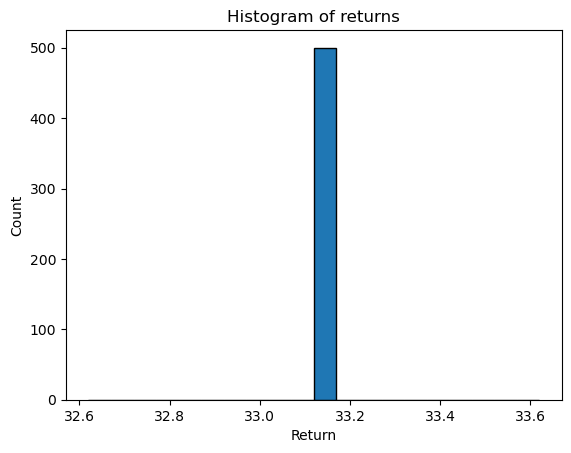

33.120000000000005


In [4]:
import matplotlib.pyplot as plt
env = GridWorld(7,size=8, danger=[7,1],goal=[4,5],wall=[2,5],coins=[(1,6),(4,2),(5,5)], horizon=50) ##set value of k here
pi = policy
# env.sparse=True
def get_return():
    s = env.reset()
    done = False
    temp = []
    while not done:
        a, _ = pi.act(s)
        s, done = env.step(a)
    return env.true_return()

temp = []
maxi = 0
for i in range(500):
    temp.append(get_return())
    maxi = max(maxi,temp[-1])
    
plt.hist(temp, bins=20, edgecolor='black')
plt.xlabel('Return')
plt.ylabel('Count')
plt.title('Histogram of returns')
plt.show()
print(maxi)